In [51]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [52]:
path_2012 = r"H:\Python\Terceiro etapa\analise_dados\atividade6\Tabela5-sem_emprego_2012.csv"
path_2026 = r"H:\Python\Terceiro etapa\analise_dados\atividade6\Tabela5-sem_emprego_2026.csv"
path_horas = r"H:\Python\Terceiro etapa\analise_dados\atividade6\Tabela 1.1.1.xls"

In [53]:
tab_2012 = pd.read_csv(path_2012, encoding="utf8", sep = ";", decimal = ",")

In [54]:
tab_2012

,Sigla,Código,Estado,Desocupados - homens (2012 T1),Desocupados - mulheres (2012 T1)
0,AC,12,Acre,45.3,54.7
1,AL,27,Alagoas,44.7,55.3
2,AM,13,Amazonas,47.5,52.5
3,AP,16,Amapá,48.1,51.9
4,BA,29,Bahia,43.8,56.2
5,CE,23,Ceará,51.1,48.9
6,DF,53,Distrito Federal,41.0,59.0
7,ES,32,Espírito Santo,46.4,53.6
8,GO,52,Goiás,41.0,59.0
9,MA,21,Maranhão,47.2,52.8


In [55]:
tab_2012 = tab_2012.rename(columns={"Desocupados - homens (2012 T1)" : "homens_2012"})
tab_2012 = tab_2012.rename(columns={"Desocupados - mulheres (2012 T1)" : "mulheres_2012"})
tab_2012

,Sigla,Código,Estado,homens_2012,mulheres_2012
0,AC,12,Acre,45.3,54.7
1,AL,27,Alagoas,44.7,55.3
2,AM,13,Amazonas,47.5,52.5
3,AP,16,Amapá,48.1,51.9
4,BA,29,Bahia,43.8,56.2
5,CE,23,Ceará,51.1,48.9
6,DF,53,Distrito Federal,41.0,59.0
7,ES,32,Espírito Santo,46.4,53.6
8,GO,52,Goiás,41.0,59.0
9,MA,21,Maranhão,47.2,52.8


In [56]:
tab_2026 = pd.read_csv(path_2026, encoding="utf8", sep = ";", decimal = ",")

In [57]:
tab_2026

,Sigla,Código,Estado,Desocupados - homens (2026 T1),Desocupados - mulheres (2026 T1)
0,AC,12,Acre,53.2,46.8
1,AL,27,Alagoas,50.7,49.3
2,AM,13,Amazonas,46.8,53.2
3,AP,16,Amapá,51.1,48.9
4,BA,29,Bahia,44.7,55.3
5,CE,23,Ceará,52.7,47.3
6,DF,53,Distrito Federal,47.9,52.1
7,ES,32,Espírito Santo,47.5,52.5
8,GO,52,Goiás,47.5,52.5
9,MA,21,Maranhão,49.1,50.9


In [58]:
tab_2026 = tab_2026.rename(columns={"Desocupados - homens (2026 T1)" : "homens_2026"})
tab_2026 = tab_2026.rename(columns={"Desocupados - mulheres (2026 T1)" : "mulheres_2026"})
tab_2026

,Sigla,Código,Estado,homens_2026,mulheres_2026
0,AC,12,Acre,53.2,46.8
1,AL,27,Alagoas,50.7,49.3
2,AM,13,Amazonas,46.8,53.2
3,AP,16,Amapá,51.1,48.9
4,BA,29,Bahia,44.7,55.3
5,CE,23,Ceará,52.7,47.3
6,DF,53,Distrito Federal,47.9,52.1
7,ES,32,Espírito Santo,47.5,52.5
8,GO,52,Goiás,47.5,52.5
9,MA,21,Maranhão,49.1,50.9


In [59]:
comp = tab_2012.merge(tab_2026, on=["Sigla", "Código", "Estado"], how="inner")
comp

,Sigla,Código,Estado,homens_2012,mulheres_2012,homens_2026,mulheres_2026
0,AC,12,Acre,45.3,54.7,53.2,46.8
1,AL,27,Alagoas,44.7,55.3,50.7,49.3
2,AM,13,Amazonas,47.5,52.5,46.8,53.2
3,AP,16,Amapá,48.1,51.9,51.1,48.9
4,BA,29,Bahia,43.8,56.2,44.7,55.3
5,CE,23,Ceará,51.1,48.9,52.7,47.3
6,DF,53,Distrito Federal,41.0,59.0,47.9,52.1
7,ES,32,Espírito Santo,46.4,53.6,47.5,52.5
8,GO,52,Goiás,41.0,59.0,47.5,52.5
9,MA,21,Maranhão,47.2,52.8,49.1,50.9


In [60]:
indicador_1 = pd.read_excel(path_horas, engine="xlrd")

#############

# Linhas 0–7: título/cabeçalho  |  8–40: resultados  |  41+: fonte e notas
indicador_1 = indicador_1.iloc[8:41].copy()
indicador_1.columns = [
    "uf_regiao",
    "total",
    "total_branca",
    "total_preta_parda",
    "homem_branca",
    "homem_preta_parda",
    "mulher_branca",
    "mulher_preta_parda",
]
indicador_1 = indicador_1.reset_index(drop=True)

# horas são número, não texto
for col in indicador_1.columns[1:]:
    indicador_1[col] = pd.to_numeric(indicador_1[col], errors="coerce")

indicador_1


,uf_regiao,total,total_branca,total_preta_parda,homem_branca,homem_preta_parda,mulher_branca,mulher_preta_parda
0,Norte,16.187037,15.925246,16.256032,11.588653,11.514646,19.295780,20.534188
1,Rondônia,17.014162,16.727733,17.101523,12.111127,12.544080,20.412887,21.061410
2,Acre,13.606903,13.806929,13.541399,10.796120,9.686983,16.130352,16.710754
3,Amazonas,16.807290,15.987545,16.995493,12.233043,12.822584,18.764969,20.716986
4,Roraima,13.639257,13.651755,13.633606,10.814803,10.476601,16.135877,16.560244
5,Pará,16.474268,16.181627,16.560239,11.524306,11.026707,19.835110,21.591144
6,Amapá,13.586656,14.389180,13.415091,11.116821,10.749444,16.648579,15.908487
7,Tocantins,15.815781,15.701788,15.768728,10.733863,11.682616,19.663713,19.629399
8,Nordeste,18.499396,18.151700,18.610911,11.723907,11.848436,22.744666,23.716716
9,Maranhão,16.669614,16.421773,16.708894,11.665173,11.437359,19.881056,20.739589


In [61]:
regioes = ["Norte", "Nordeste", "Sudeste", "Sul", "Centro_Oeste"]

In [62]:
estados = indicador_1[~indicador_1["uf_regiao"].isin(["Brasil"] + regioes)]

In [66]:
indicador_1 = indicador_1.rename(columns={"uf_regiao" : "Estado"})

In [67]:
indicador_1

,Estado,total,total_branca,total_preta_parda,homem_branca,homem_preta_parda,mulher_branca,mulher_preta_parda
0,Norte,16.187037,15.925246,16.256032,11.588653,11.514646,19.295780,20.534188
1,Rondônia,17.014162,16.727733,17.101523,12.111127,12.544080,20.412887,21.061410
2,Acre,13.606903,13.806929,13.541399,10.796120,9.686983,16.130352,16.710754
3,Amazonas,16.807290,15.987545,16.995493,12.233043,12.822584,18.764969,20.716986
4,Roraima,13.639257,13.651755,13.633606,10.814803,10.476601,16.135877,16.560244
5,Pará,16.474268,16.181627,16.560239,11.524306,11.026707,19.835110,21.591144
6,Amapá,13.586656,14.389180,13.415091,11.116821,10.749444,16.648579,15.908487
7,Tocantins,15.815781,15.701788,15.768728,10.733863,11.682616,19.663713,19.629399
8,Nordeste,18.499396,18.151700,18.610911,11.723907,11.848436,22.744666,23.716716
9,Maranhão,16.669614,16.421773,16.708894,11.665173,11.437359,19.881056,20.739589


In [68]:
comp2 = comp.merge(indicador_1, on=["Estado"], how="inner")
comp2

,Sigla,Código,Estado,homens_2012,mulheres_2012,homens_2026,mulheres_2026,total,total_branca,total_preta_parda,homem_branca,homem_preta_parda,mulher_branca,mulher_preta_parda
0,AC,12,Acre,45.3,54.7,53.2,46.8,13.606903,13.806929,13.541399,10.796120,9.686983,16.130352,16.710754
1,AL,27,Alagoas,44.7,55.3,50.7,49.3,20.217129,19.165111,20.560451,12.121839,13.357160,24.093655,25.856637
2,AM,13,Amazonas,47.5,52.5,46.8,53.2,16.807290,15.987545,16.995493,12.233043,12.822584,18.764969,20.716986
3,AP,16,Amapá,48.1,51.9,51.1,48.9,13.586656,14.389180,13.415091,11.116821,10.749444,16.648579,15.908487
4,BA,29,Bahia,43.8,56.2,44.7,55.3,17.849776,17.538007,17.935566,10.551673,10.982808,22.572730,23.217119
5,CE,23,Ceará,51.1,48.9,52.7,47.3,19.499293,18.527120,19.882469,12.186936,12.821323,23.019718,24.952274
6,DF,53,Distrito Federal,41.0,59.0,47.9,52.1,15.096351,15.061306,15.126295,11.377952,10.481279,17.738123,19.307332
7,ES,32,Espírito Santo,46.4,53.6,47.5,52.5,17.111106,16.510610,17.478861,11.798571,12.017589,20.464462,22.196626
8,GO,52,Goiás,41.0,59.0,47.5,52.5,15.186471,14.962622,15.296966,10.636424,10.531883,18.440842,19.587913
9,MA,21,Maranhão,47.2,52.8,49.1,50.9,16.669614,16.421773,16.708894,11.665173,11.437359,19.881056,20.739589


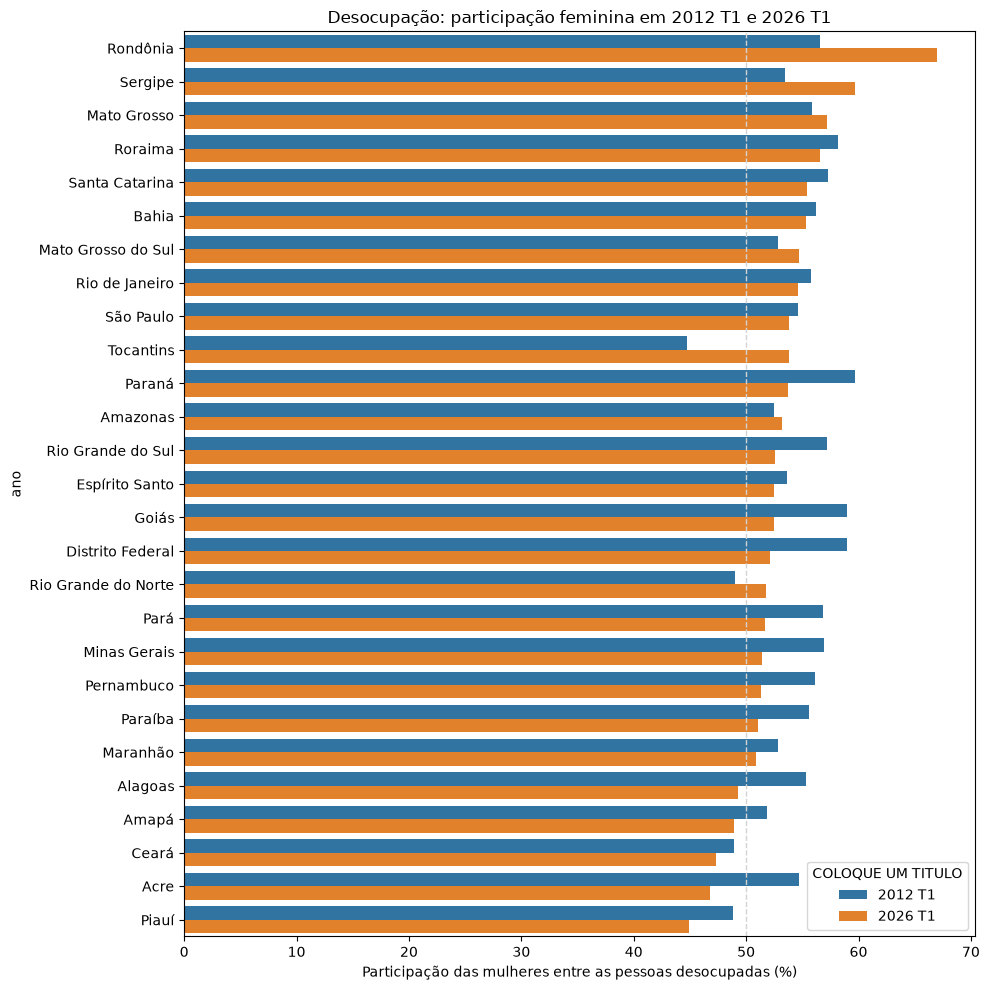

In [71]:
ordem = comp2.sort_values("mulheres_2026", ascending=False)["Estado"]
longo = comp.melt(
    id_vars=["Estado"],
    value_vars=["mulheres_2012", "mulheres_2026"],
    var_name="Ano",
    value_name="Participacao_mulheres",
)
longo["Ano"] = longo["Ano"].map({"mulheres_2012": "2012 T1", "mulheres_2026": "2026 T1"})

fig, ax = plt.subplots(figsize=(10, 10))
sns.barplot(
    data=longo,
    y="Estado",
    x="Participacao_mulheres",
    hue="Ano",
    order=ordem,
    ax=ax,
)
ax.axvline(50, color="lightgray", linestyle="--", linewidth=1) # MUDE A COR
ax.set_xlabel("Participação das mulheres entre as pessoas desocupadas (%)")
ax.set_ylabel("ano")
ax.set_title("Desocupação: participação feminina em 2012 T1 e 2026 T1")
ax.legend(title="COLOQUE UM TITULO")
fig.tight_layout()